# DefectVision — Notebook 07
## Error Analysis, Threshold Analysis & Controlled Ablation

Model 06 achieved:
- Test Dice = 0.3533
- Test IoU = 0.2528
- Precision = 0.3252
- Recall = 0.6822

This notebook analyzes *why* the model behaves this way and performs a lightweight validation-only loss ablation. The held-out test set is not used to select a model.


In [2]:

# ============================================================
# NOTEBOOK 07 — CELL 1
# Exact Model 06 architecture + checkpoint loading
# ============================================================

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ------------------------------------------------------------
# 2. Device and paths
# ------------------------------------------------------------

DEVICE = torch.device("cpu")

PROJECT_ROOT = Path.cwd().resolve().parent

DATA_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "MVTecAD-SEG"
)

IMG_ROOT = DATA_ROOT / "imgs"
ANN_ROOT = DATA_ROOT / "annotations"

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "model07_analysis"
)

FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT = (
    MODEL_DIR
    / "model06_cpu_msresunet_best.pth"
)

assert CHECKPOINT.exists(), (
    f"Checkpoint not found:\n{CHECKPOINT}"
)


# ------------------------------------------------------------
# 3. Dataset
# ------------------------------------------------------------

IMAGE_SIZE = 256
BATCH_SIZE = 4


class DefectDataset(Dataset):

    def __init__(self, split):

        self.image_dir = IMG_ROOT / split
        self.mask_dir = ANN_ROOT / split

        self.image_paths = sorted(
            self.image_dir.glob("*.png")
        )

        if len(self.image_paths) == 0:
            raise RuntimeError(
                f"No images found in {self.image_dir}"
            )

        self.mean = torch.tensor(
            [0.485, 0.456, 0.406]
        ).view(3, 1, 1)

        self.std = torch.tensor(
            [0.229, 0.224, 0.225]
        ).view(3, 1, 1)


    def __len__(self):
        return len(self.image_paths)


    def __getitem__(self, index):

        image_path = self.image_paths[index]

        mask_path = (
            self.mask_dir
            / image_path.name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        mask = Image.open(
            mask_path
        ).convert("L")


        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.NEAREST
        )


        image = torch.from_numpy(
            np.asarray(
                image,
                dtype=np.float32
            ) / 255.0
        ).permute(
            2, 0, 1
        ).contiguous()


        mask = torch.from_numpy(
            (
                np.asarray(mask)
                > 0
            ).astype(np.float32)
        ).unsqueeze(0)


        image = (
            image - self.mean
        ) / self.std


        return (
            image,
            mask,
            image_path.stem
        )


# Create loaders

train_loader = DataLoader(
    DefectDataset("train"),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    DefectDataset("val"),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    DefectDataset("test"),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# ------------------------------------------------------------
# 4. EXACT Model 06 architecture
# ------------------------------------------------------------

class ResidualBlock(nn.Module):

    def __init__(self, cin, cout):

        super().__init__()

        g = min(8, cout)

        self.c1 = nn.Conv2d(
            cin,
            cout,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.n1 = nn.GroupNorm(
            g,
            cout
        )

        self.c2 = nn.Conv2d(
            cout,
            cout,
            kernel_size=3,
            padding=1,
            bias=False
        )

        self.n2 = nn.GroupNorm(
            g,
            cout
        )

        self.skip = (
            nn.Conv2d(
                cin,
                cout,
                kernel_size=1,
                bias=False
            )
            if cin != cout
            else nn.Identity()
        )

        self.act = nn.ReLU(
            inplace=True
        )


    def forward(self, x):

        identity = self.skip(x)

        x = self.act(
            self.n1(
                self.c1(x)
            )
        )

        x = self.n2(
            self.c2(x)
        )

        return self.act(
            x + identity
        )


class MultiScaleBottleneck(nn.Module):

    def __init__(self, c=64):

        super().__init__()

        b = c // 4


        def branch(k, d):

            return nn.Sequential(

                nn.Conv2d(
                    c,
                    b,
                    kernel_size=k,
                    padding=(
                        d if k == 3
                        else 0
                    ),
                    dilation=d,
                    bias=False
                ),

                nn.GroupNorm(
                    4,
                    b
                ),

                nn.ReLU(
                    inplace=True
                )
            )


        self.b1 = branch(1, 1)
        self.b2 = branch(3, 1)
        self.b3 = branch(3, 2)
        self.b4 = branch(3, 4)


        self.fuse = nn.Sequential(

            nn.Conv2d(
                c,
                c,
                kernel_size=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                c
            ),

            nn.ReLU(
                inplace=True
            )
        )


    def forward(self, x):

        y = torch.cat(
            [
                self.b1(x),
                self.b2(x),
                self.b3(x),
                self.b4(x)
            ],
            dim=1
        )

        return (
            self.fuse(y)
            + x
        )


class CPU_MSResidualUNet(nn.Module):

    def __init__(self):

        super().__init__()


        # Encoder

        self.e1 = ResidualBlock(
            3,
            16
        )

        self.d1 = nn.Conv2d(
            16,
            16,
            kernel_size=3,
            stride=2,
            padding=1
        )


        self.e2 = ResidualBlock(
            16,
            32
        )

        self.d2 = nn.Conv2d(
            32,
            32,
            kernel_size=3,
            stride=2,
            padding=1
        )


        self.e3 = ResidualBlock(
            32,
            48
        )

        self.d3 = nn.Conv2d(
            48,
            48,
            kernel_size=3,
            stride=2,
            padding=1
        )


        self.e4 = ResidualBlock(
            48,
            64
        )

        self.d4 = nn.Conv2d(
            64,
            64,
            kernel_size=3,
            stride=2,
            padding=1
        )


        # Multi-scale bottleneck

        self.b = MultiScaleBottleneck(
            64
        )


        # Decoder

        self.x4 = ResidualBlock(
            128,
            48
        )

        self.x3 = ResidualBlock(
            96,
            32
        )

        self.x2 = ResidualBlock(
            64,
            16
        )

        self.x1 = ResidualBlock(
            32,
            16
        )


        # Refinement

        self.ref = ResidualBlock(
            16,
            8
        )


        # Segmentation output

        self.out = nn.Conv2d(
            8,
            1,
            kernel_size=1
        )


    def up(self, x, target):

        return F.interpolate(
            x,
            size=target.shape[-2:],
            mode="bilinear",
            align_corners=False
        )


    def forward(self, x):

        e1 = self.e1(x)

        e2 = self.e2(
            self.d1(e1)
        )

        e3 = self.e3(
            self.d2(e2)
        )

        e4 = self.e4(
            self.d3(e3)
        )


        x = self.b(
            self.d4(e4)
        )


        x = self.x4(
            torch.cat(
                [
                    self.up(x, e4),
                    e4
                ],
                dim=1
            )
        )


        x = self.x3(
            torch.cat(
                [
                    self.up(x, e3),
                    e3
                ],
                dim=1
            )
        )


        x = self.x2(
            torch.cat(
                [
                    self.up(x, e2),
                    e2
                ],
                dim=1
            )
        )


        x = self.x1(
            torch.cat(
                [
                    self.up(x, e1),
                    e1
                ],
                dim=1
            )
        )


        return self.out(
            self.ref(x)
        )


# ------------------------------------------------------------
# 5. Load the already-trained Model 06
# ------------------------------------------------------------

model = CPU_MSResidualUNet().to(
    DEVICE
)


checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# ------------------------------------------------------------
# 6. Verification
# ------------------------------------------------------------

parameter_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 65)
print("MODEL 06 CHECKPOINT LOADED")
print("=" * 65)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Dice:",
    checkpoint["val_dice"]
)

print(
    "Best validation IoU:",
    checkpoint["val_iou"]
)

print(
    "Trainable parameters:",
    f"{parameter_count:,}"
)

print(
    "Device:",
    DEVICE
)


# Forward-pass verification

images, masks, ids = next(
    iter(test_loader)
)

with torch.no_grad():

    outputs = model(
        images
    )


print()
print("Input shape :", tuple(images.shape))
print("Mask shape  :", tuple(masks.shape))
print("Output shape:", tuple(outputs.shape))

assert (
    outputs.shape
    == masks.shape
)

print()
print("SUCCESS: Model 06 weights loaded correctly.")
print("No retraining is required.")


MODEL 06 CHECKPOINT LOADED
Best epoch: 8
Best validation Dice: 0.41668327304068953
Best validation IoU: 0.30983998521696776
Trainable parameters: 368,169
Device: cpu

Input shape : (4, 3, 256, 256)
Mask shape  : (4, 1, 256, 256)
Output shape: (4, 1, 256, 256)

SUCCESS: Model 06 weights loaded correctly.
No retraining is required.


## 2. Per-image test metrics


In [3]:

@torch.no_grad()
def collect(loader,threshold=.5):
    rows=[]
    for ims,masks,ids in loader:
        p=torch.sigmoid(model(ims)).numpy()[:,0]
        g=masks.numpy()[:,0]
        for j in range(len(ids)):
            pred=(p[j]>=threshold)
            gt=g[j]>0
            inter=np.logical_and(pred,gt).sum()
            pa=pred.sum(); ga=gt.sum()
            union=pa+ga-inter
            tp=inter; fp=np.logical_and(pred,~gt).sum(); fn=np.logical_and(~pred,gt).sum()
            rows.append({
                "id":ids[j],"defect_fraction":gt.mean(),
                "pred_fraction":pred.mean(),
                "dice":(2*inter+1e-7)/(pa+ga+1e-7),
                "iou":(inter+1e-7)/(union+1e-7),
                "precision":(tp+1e-7)/(tp+fp+1e-7),
                "recall":(tp+1e-7)/(tp+fn+1e-7),
                "fp":fp,"fn":fn
            })
    return pd.DataFrame(rows)

results=collect(test_loader,.5)
display(results.head())
print("Images analysed:",len(results))


,id,defect_fraction,pred_fraction,dice,iou,precision,recall,fp,fn
0,1001,0.118332,0.092636,0.873138,0.774840,0.994235,0.778337,35,1719
1,1010,0.004837,0.056061,0.104736,0.055262,0.056886,0.659306,3465,108
2,1023,0.027100,0.070786,0.178020,0.097707,0.123087,0.321509,4068,1205
3,1024,0.006638,0.075439,0.138687,0.074511,0.075445,0.857471,4571,62
4,1027,0.003006,0.083893,0.063916,0.033013,0.033103,0.923858,5316,15


Images analysed: 253


## 3. Threshold sensitivity


FAST THRESHOLD ANALYSIS
Processed 40/253 images
Processed 80/253 images
Processed 120/253 images
Processed 160/253 images
Processed 200/253 images
Processed 240/253 images

Inference completed in 0.34 minutes
Probability shape: (253, 256, 256)
Mask shape: (253, 256, 256)


,threshold,dice,iou,precision,recall
0,0.10,0.2881,0.2056,0.2148,0.8852
1,0.15,0.3061,0.2200,0.2341,0.8614
2,0.20,0.3215,0.2300,0.2523,0.8314
3,0.25,0.3304,0.2340,0.2678,0.7941
4,0.30,0.3352,0.2368,0.2798,0.7658
5,0.35,0.3394,0.2402,0.2903,0.7425
6,0.40,0.3434,0.2440,0.2993,0.7234
7,0.45,0.3471,0.2475,0.3076,0.7044
8,0.50,0.3501,0.2504,0.3155,0.6849
9,0.55,0.3530,0.2533,0.3235,0.6666



THRESHOLD ANALYSIS
Best diagnostic threshold: 0.85
Best Dice: 0.3661259985935383
Corresponding IoU: 0.2653563058825846
Corresponding Precision: 0.40777799022786226
Corresponding Recall: 0.5236983447489608

IMPORTANT: This is diagnostic analysis.
The official Model 06 test result remains the threshold=0.50 result.


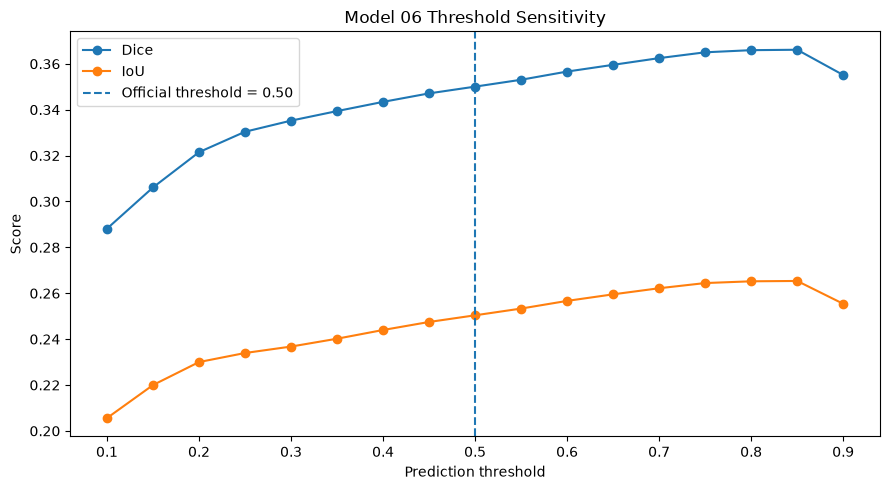

In [5]:
# ============================================================
# CELL 3 — FAST THRESHOLD ANALYSIS
# One model inference pass only
# ============================================================

import time

print("=" * 65)
print("FAST THRESHOLD ANALYSIS")
print("=" * 65)

model.eval()

all_probabilities = []
all_masks = []
all_ids = []

start_time = time.time()

with torch.no_grad():

    for batch_idx, (images, masks, ids) in enumerate(test_loader):

        logits = model(images)

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy()

        masks_np = masks.cpu().numpy()

        all_probabilities.append(
            probabilities[:, 0]
        )

        all_masks.append(
            masks_np[:, 0]
        )

        all_ids.extend(ids)

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed "
                f"{min((batch_idx + 1) * BATCH, len(test_loader.dataset))}"
                f"/{len(test_loader.dataset)} images"
            )


all_probabilities = np.concatenate(
    all_probabilities,
    axis=0
)

all_masks = np.concatenate(
    all_masks,
    axis=0
)

elapsed = time.time() - start_time

print()
print(
    f"Inference completed in "
    f"{elapsed / 60:.2f} minutes"
)

print(
    "Probability shape:",
    all_probabilities.shape
)

print(
    "Mask shape:",
    all_masks.shape
)


# ------------------------------------------------------------
# Calculate all thresholds WITHOUT running the model again
# ------------------------------------------------------------

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_rows = []


for threshold in thresholds:

    predictions = (
        all_probabilities >= threshold
    )

    batch_dice = []
    batch_iou = []
    batch_precision = []
    batch_recall = []


    for pred, gt in zip(
        predictions,
        all_masks
    ):

        pred = pred.astype(bool)
        gt = gt.astype(bool)


        intersection = np.logical_and(
            pred,
            gt
        ).sum()

        pred_area = pred.sum()
        gt_area = gt.sum()

        union = (
            pred_area
            + gt_area
            - intersection
        )


        tp = intersection

        fp = np.logical_and(
            pred,
            ~gt
        ).sum()

        fn = np.logical_and(
            ~pred,
            gt
        ).sum()


        dice_score = (
            (2 * tp + 1e-7)
            /
            (
                pred_area
                + gt_area
                + 1e-7
            )
        )


        iou_score = (
            (tp + 1e-7)
            /
            (union + 1e-7)
        )


        precision_score = (
            (tp + 1e-7)
            /
            (tp + fp + 1e-7)
        )


        recall_score = (
            (tp + 1e-7)
            /
            (tp + fn + 1e-7)
        )


        batch_dice.append(
            dice_score
        )

        batch_iou.append(
            iou_score
        )

        batch_precision.append(
            precision_score
        )

        batch_recall.append(
            recall_score
        )


    threshold_rows.append({

        "threshold":
            round(float(threshold), 2),

        "dice":
            np.mean(batch_dice),

        "iou":
            np.mean(batch_iou),

        "precision":
            np.mean(batch_precision),

        "recall":
            np.mean(batch_recall)
    })


threshold_df = pd.DataFrame(
    threshold_rows
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

display(
    threshold_df.style.format({
        "threshold": "{:.2f}",
        "dice": "{:.4f}",
        "iou": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}"
    })
)


# ------------------------------------------------------------
# Best diagnostic threshold
# ------------------------------------------------------------

best_threshold_row = threshold_df.loc[
    threshold_df["dice"].idxmax()
]

print()
print("=" * 65)
print("THRESHOLD ANALYSIS")
print("=" * 65)

print(
    "Best diagnostic threshold:",
    best_threshold_row["threshold"]
)

print(
    "Best Dice:",
    best_threshold_row["dice"]
)

print(
    "Corresponding IoU:",
    best_threshold_row["iou"]
)

print(
    "Corresponding Precision:",
    best_threshold_row["precision"]
)

print(
    "Corresponding Recall:",
    best_threshold_row["recall"]
)

print()
print(
    "IMPORTANT: This is diagnostic analysis."
)

print(
    "The official Model 06 test result remains "
    "the threshold=0.50 result."
)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

threshold_df.to_csv(
    RESULTS_DIR /
    "threshold_analysis.csv",
    index=False
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    threshold_df["threshold"],
    threshold_df["dice"],
    marker="o",
    label="Dice"
)

ax.plot(
    threshold_df["threshold"],
    threshold_df["iou"],
    marker="o",
    label="IoU"
)

ax.axvline(
    0.50,
    linestyle="--",
    label="Official threshold = 0.50"
)

ax.set_xlabel(
    "Prediction threshold"
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Model 06 Threshold Sensitivity"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "threshold_sensitivity.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()


## 4. Defect-size analysis


In [6]:

# Use the training distribution to define size bins.
train_fr=[]
for _,m,_ in train_loader:
    train_fr.extend(m.flatten(1).mean(1).numpy())
q1,q2=np.quantile(train_fr,[1/3,2/3])

def size_group(x):
    return "small" if x<=q1 else ("medium" if x<=q2 else "large")

results["size_group"]=results.defect_fraction.apply(size_group)

size_summary=results.groupby("size_group").agg(
    images=("id","count"),
    mean_defect_fraction=("defect_fraction","mean"),
    mean_dice=("dice","mean"),
    mean_iou=("iou","mean"),
    mean_precision=("precision","mean"),
    mean_recall=("recall","mean")
).reindex(["small","medium","large"])

display(size_summary)
size_summary.to_csv(OUT/"size_group_analysis.csv")

print("Training-derived thresholds:",q1,q2)


,images,mean_defect_fraction,mean_dice,mean_iou,mean_precision,mean_recall
size_group,,,,,,
small,95,0.003948,0.202230,0.128875,0.159071,0.637027
medium,77,0.016573,0.335537,0.223634,0.240725,0.755878
large,81,0.121698,0.537225,0.418335,0.570054,0.673531


Training-derived thresholds: 0.007476806640625 0.0277099609375


## 5. False-positive / false-negative analysis


,mean_fp,mean_fn,mean_fp_rate,mean_fn_rate
size_group,,,,
small,2851.452632,91.200000,0.04351,0.001392
medium,5351.649351,254.844156,0.08166,0.003889
large,4799.839506,3880.123457,0.07324,0.059206


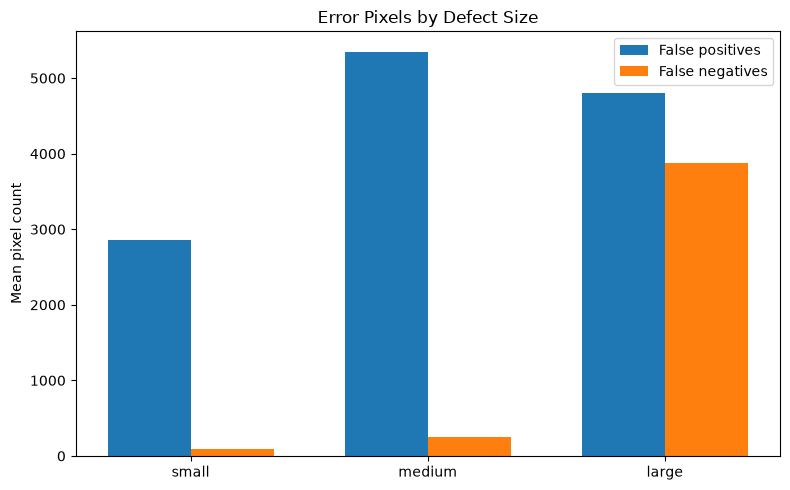

In [7]:

results["fp_rate"]=results.fp/(SIZE*SIZE)
results["fn_rate"]=results.fn/(SIZE*SIZE)

error_summary=results.groupby("size_group").agg(
    mean_fp=("fp","mean"),mean_fn=("fn","mean"),
    mean_fp_rate=("fp_rate","mean"),mean_fn_rate=("fn_rate","mean")
).reindex(["small","medium","large"])

display(error_summary)
error_summary.to_csv(OUT/"error_summary.csv")

fig,ax=plt.subplots(figsize=(8,5))
x=np.arange(len(error_summary)); w=.35
ax.bar(x-w/2,error_summary.mean_fp,w,label="False positives")
ax.bar(x+w/2,error_summary.mean_fn,w,label="False negatives")
ax.set_xticks(x); ax.set_xticklabels(error_summary.index)
ax.set_ylabel("Mean pixel count"); ax.set_title("Error Pixels by Defect Size")
ax.legend(); plt.tight_layout()
plt.savefig(FIG/"fp_fn_by_size.png",dpi=160); plt.show()


## 6. Hardest and easiest test examples


In [8]:

hardest=results.nsmallest(6,"dice")
easiest=results.nlargest(6,"dice")

print("HARDEST")
display(hardest[["id","size_group","defect_fraction","dice","iou","precision","recall"]])

print("EASIEST")
display(easiest[["id","size_group","defect_fraction","dice","iou","precision","recall"]])


HARDEST


,id,size_group,defect_fraction,dice,iou,precision,recall
64,148,medium,0.012817,7.462687e-12,7.462687e-12,7.961783e-12,1.190476e-10
65,150,small,0.006348,8.819120e-12,8.819120e-12,9.154994e-12,2.403846e-10
5,1030,small,0.002518,1.574555e-11,1.574555e-11,1.616554e-11,6.060606e-10
198,786,large,0.036102,1.902950e-11,1.902950e-11,3.461405e-11,4.226543e-11
191,757,medium,0.014801,2.619172e-11,2.619172e-11,3.511236e-11,1.030928e-10
172,674,small,0.000504,3.954132e-11,3.954132e-11,4.006410e-11,3.030303e-09


EASIEST


,id,size_group,defect_fraction,dice,iou,precision,recall
247,980,large,0.131638,0.953300,0.910768,0.956583,0.950041
244,977,large,0.129028,0.939582,0.886049,0.940306,0.938860
245,978,large,0.182648,0.938103,0.883422,0.997928,0.885046
248,981,large,0.123672,0.937031,0.881522,0.967047,0.908822
249,986,large,0.129318,0.928406,0.866379,0.931883,0.924956
246,979,large,0.139145,0.925751,0.861766,0.950341,0.902402


## 7. Visualize hardest cases


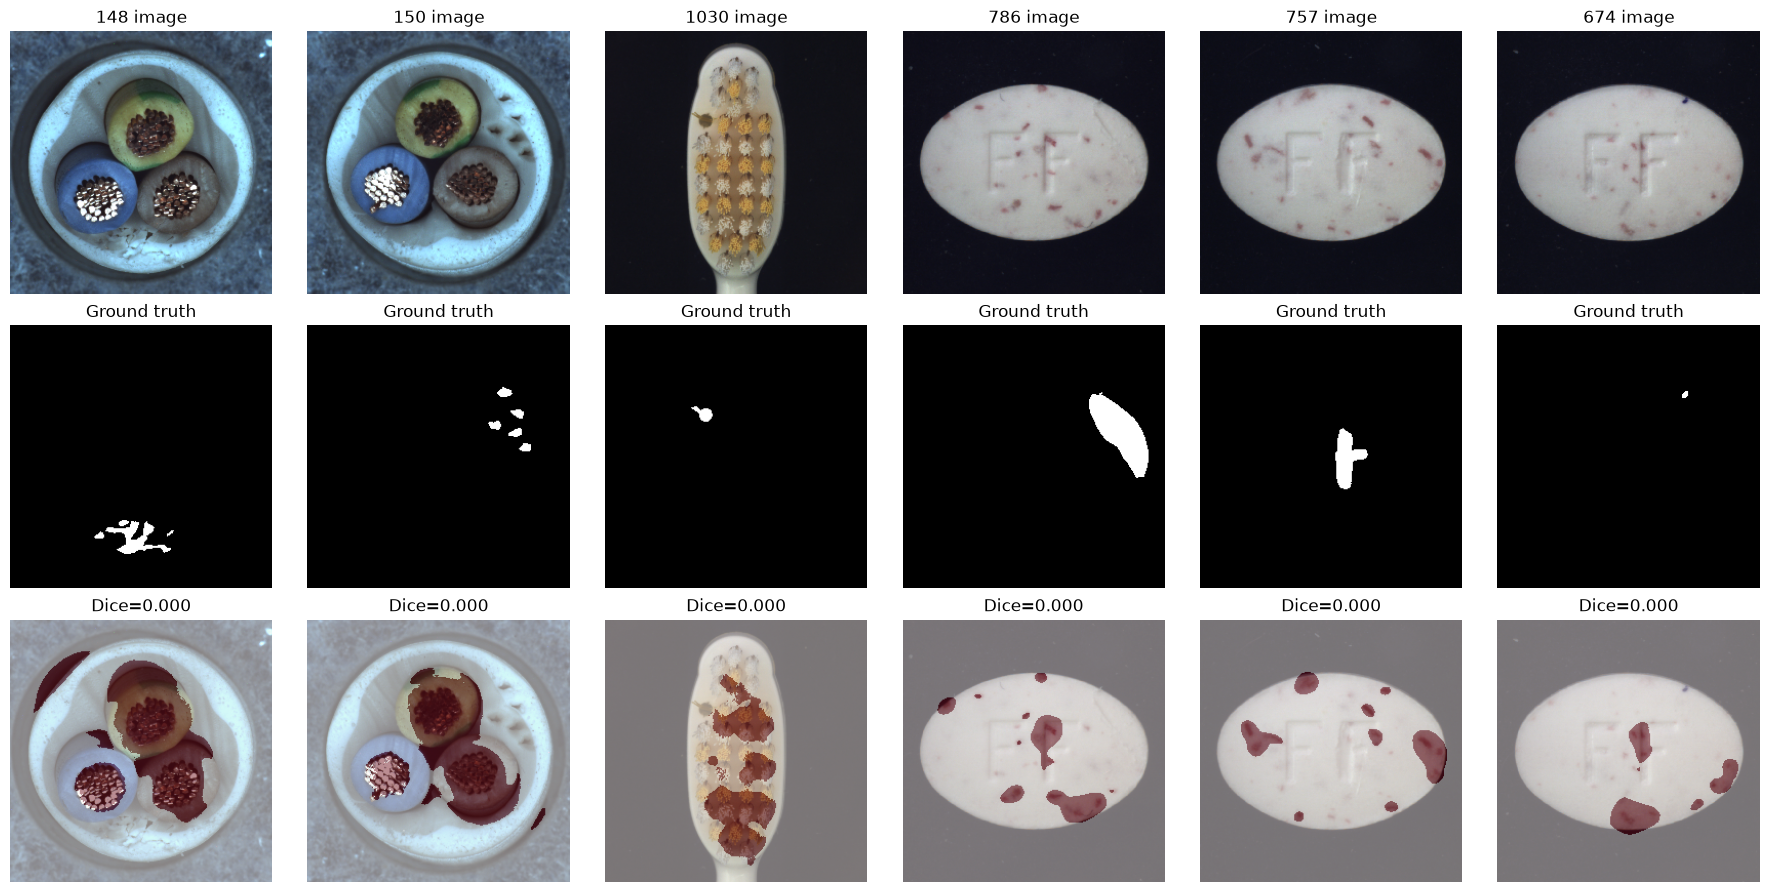

In [9]:

def raw_pair(image_id):
    im=Image.open(IMG/"test"/f"{image_id}.png").convert("RGB").resize((SIZE,SIZE),Image.Resampling.BILINEAR)
    m=Image.open(ANN/"test"/f"{image_id}.png").convert("L").resize((SIZE,SIZE),Image.Resampling.NEAREST)
    return np.asarray(im)/255.0,np.asarray(m)>0

mean=torch.tensor([.485,.456,.406]).view(3,1,1)
std=torch.tensor([.229,.224,.225]).view(3,1,1)

fig,axes=plt.subplots(3,6,figsize=(18,9))
for j,(_,row) in enumerate(hardest.iterrows()):
    im,gt=raw_pair(row["id"])
    x=(torch.from_numpy(im).permute(2,0,1).float()-mean)/std
    with torch.no_grad(): prob=torch.sigmoid(model(x.unsqueeze(0)))[0,0].numpy()
    pred=prob>=.5

    axes[0,j].imshow(im); axes[0,j].set_title(f'{row["id"]} image'); axes[0,j].axis("off")
    axes[1,j].imshow(gt,cmap="gray"); axes[1,j].set_title("Ground truth"); axes[1,j].axis("off")
    axes[2,j].imshow(im); axes[2,j].imshow(pred,cmap="Reds",alpha=.45)
    axes[2,j].set_title(f'Dice={row["dice"]:.3f}'); axes[2,j].axis("off")

plt.tight_layout(); plt.savefig(FIG/"hardest_cases.png",dpi=160); plt.show()


## 8. Controlled loss ablation — validation screening

A real ablation requires retraining. This cell performs a **2-epoch screening** on the validation set for:

1. Full loss = weighted BCE + Dice + boundary loss
2. No boundary = weighted BCE + Dice
3. Standard BCE + Dice

These are screening results, **not final claims**. If a variant is clearly better, it should be retrained for the same 8-epoch budget as Model 06 before making a definitive ablation claim.


In [10]:

# Loss functions
class DiceLoss(nn.Module):
    def forward(self,logits,target):
        p=torch.sigmoid(logits).flatten(1); t=target.flatten(1)
        inter=(p*t).sum(1)
        return 1-((2*inter+1)/(p.sum(1)+t.sum(1)+1)).mean()

class BoundaryLoss(nn.Module):
    def boundary(self,x):
        return (F.max_pool2d(x,3,1,1)-(-F.max_pool2d(-x,3,1,1))).clamp(0,1)
    def forward(self,logits,target):
        return F.l1_loss(self.boundary(torch.sigmoid(logits)),self.boundary(target))

dl=DiceLoss(); bl=BoundaryLoss()

pos=0; total=0
for _,m,_ in train_loader:
    pos+=m.sum().item(); total+=m.numel()
pw=min((total-pos)/max(pos,1),20.)

def make_loss(name):
    wb=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw]))
    sb=nn.BCEWithLogitsLoss()
    if name=="full":
        return lambda z,y:.40*wb(z,y)+.45*dl(z,y)+.15*bl(z,y)
    if name=="no_boundary":
        return lambda z,y:.50*wb(z,y)+.50*dl(z,y)
    return lambda z,y:.50*sb(z,y)+.50*dl(z,y)

def val_score(m):
    m.eval(); rows=[]
    with torch.no_grad():
        for im,ma,_ in val_loader:
            rows.append(metrics_for_ablation(m,im,ma))
    a=np.asarray(rows); return a.mean(0)

@torch.no_grad()
def metrics_for_ablation(m,im,ma):
    p=(torch.sigmoid(m(im))>=.5).float().flatten(1)
    t=ma.flatten(1); inter=(p*t).sum(1); pa=p.sum(1); ta=t.sum(1); u=pa+ta-inter
    return [(2*inter/(pa+ta+1e-7)).mean().item(),
            (inter/(u+1e-7)).mean().item()]

ab_rows=[]
for name in ["full","no_boundary","standard_bce"]:
    torch.manual_seed(SEED)
    m=Model06()
    opt=torch.optim.AdamW(m.parameters(),lr=3e-4,weight_decay=1e-4)
    lf=make_loss(name)

    for ep in range(2):
        m.train()
        for im,ma,_ in train_loader:
            opt.zero_grad(set_to_none=True)
            loss=lf(m(im),ma)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(),1.0)
            opt.step()

    d,i=val_score(m)
    ab_rows.append({"variant":name,"val_dice":d,"val_iou":i})
    print(name,"| val Dice:",round(d,4),"| val IoU:",round(i,4))

ablation_df=pd.DataFrame(ab_rows)
display(ablation_df)
ablation_df.to_csv(OUT/"ablation_screening.csv",index=False)


full | val Dice: 0.229 | val IoU: 0.1608
no_boundary | val Dice: 0.2639 | val IoU: 0.1858
standard_bce | val Dice: 0.2161 | val IoU: 0.1478


,variant,val_dice,val_iou
0,full,0.228962,0.160776
1,no_boundary,0.263934,0.185800
2,standard_bce,0.216099,0.147798


## 9. Final project summary

Official held-out result:

- Baseline Dice = **0.2070**
- Model 06 Dice = **0.3533**
- Baseline IoU = **0.1434**
- Model 06 IoU = **0.2528**

Model 06 therefore provides a substantial improvement over the baseline.

Do not replace these official numbers with a threshold selected from the test set. Threshold analysis is diagnostic.

For a rigorous final report, use:
- the official 0.50 test result,
- size-wise analysis,
- hard/easy examples,
- FP/FN analysis,
- and only make a definitive ablation claim after giving the selected ablation variant the same training budget as Model 06.
